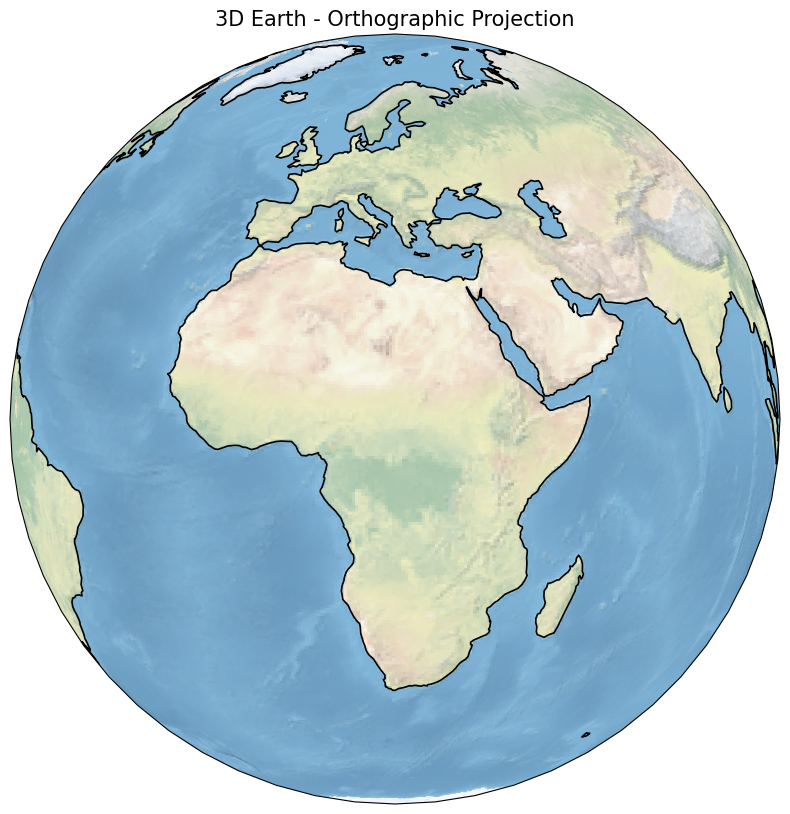

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_3d_earth():
    # 1. 设置投影模式：Orthographic (正射投影) 就是这种“从太空看地球”的 3D 球体效果
    # central_longitude 和 central_latitude 用来控制地球旋转的角度
    # 根据你的图片，中心大概在非洲附近 (经度 20, 纬度 10 左右)
    projection = ccrs.Orthographic(central_longitude=20, central_latitude=10)

    # 2. 创建画布
    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=projection)

    # 3. 添加底图 (Stock Image)
    # cartopy 自带的一个低分辨率地形图，颜色风格和你图片非常接近
    ax.stock_img()

    # 4. 添加海岸线
    # resolution='110m' 是精度，color='black' 设置为黑色线条以匹配你的参考图
    ax.coastlines(resolution='110m', color='black', linewidth=1.2)

    # 5. (可选) 添加国界线，如果你希望更像地图一点
    # ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

    # 6. 确保显示整个地球（不要裁剪）
    ax.set_global()

    # 7. 去除边框背景，使其更像一个悬浮的球体
    # 如果不想要外面的方框，可以关闭 axis
    # ax.axis('off')

    # 加上标题
    plt.title("3D Earth - Orthographic Projection", fontsize=15)

    plt.show()

if __name__ == "__main__":
    plot_3d_earth()

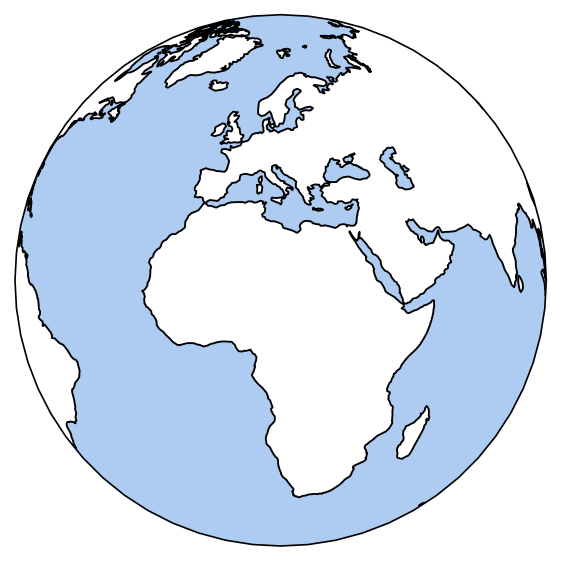

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def show_globe_like_example(center_lon=15, center_lat=20, figsize=(4.6, 4.6), dpi=150):
    ocean_fc = "#AECCF2"  # RGB(174,204,242)
    land_fc  = "#FFFFFF"

    proj = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.axes(projection=proj)
    ax.set_global()

    # 兼容不同 cartopy 版本
    if hasattr(ax, "background_patch"):
        ax.background_patch.set_visible(False)
    else:
        ax.patch.set_visible(False)

    # 海陆
    ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor=ocean_fc, edgecolor="none")
    ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor=land_fc, edgecolor="none")

    # 海岸线
    ax.coastlines(resolution="110m", linewidth=0.9, color="black")

    # 地球外轮廓稍加粗
    try:
        ax.outline_patch.set_linewidth(1.2)
        ax.outline_patch.set_edgecolor("black")
    except Exception:
        pass

    plt.show()

# 直接预览
show_globe_like_example()


In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def save_globe_4k_square(
    out="globe_4k_square.png",
    center_lon=15,
    center_lat=20,
):
    ocean_fc = "#AECCF2"  # RGB(174,204,242)
    land_fc  = "#FFFFFF"

    # 目标像素
    px = 3840
    dpi = 600
    figsize = (px / dpi, px / dpi)  # (6.4, 6.4) inches

    proj = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.axes(projection=proj)
    ax.set_global()

    # 兼容不同版本背景处理
    fig.patch.set_alpha(0)
    if hasattr(ax, "background_patch"):
        ax.background_patch.set_visible(False)
    else:
        ax.patch.set_visible(False)

    ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor=ocean_fc, edgecolor="none")
    ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor=land_fc, edgecolor="none")
    ax.coastlines(resolution="110m", linewidth=0.9, color="black")

    try:
        ax.outline_patch.set_linewidth(1.2)
        ax.outline_patch.set_edgecolor("black")
    except Exception:
        pass

    fig.savefig(out, dpi=dpi, bbox_inches="tight", pad_inches=0.02, transparent=True)
    plt.close(fig)
    print("Saved:", out)

# 用法
save_globe_4k_square()


Saved: globe_4k_square.png
